In [1]:
!pip install torch torchvision torchaudio
!pip install scikit-learn matplotlib numpy seaborn
!pip install efficientnet-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 37.6 MB/s  0:00:02 eta 0:00:010:01:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 12.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 737.1/737.1 kB 19.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 46.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 kB 33.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [torchaudio] 6/7 [torchaudio]hvision]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 43.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 48.5 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 45.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [seaborn]━  9/1

In [6]:
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

# Resizing to 380x380 is required for EfficientNet-B4
base_transform = transforms.Compose([
    transforms.Resize((380, 380)), 
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. SOTA Preprocessing
augment_transform = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.AutoAugment(policy=transforms.AutoAugmentPolicy.IMAGENET),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
print("All  Preprocessing done")

All  Preprocessing done


In [9]:
!mkdir -p /Users/aakash/.cache/torch/hub/checkpoints/
!curl -L https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth -o /Users/aakash/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 74.4M  100 74.4M    0     0  16.3M      0  0:00:04  0:00:04 --:--:-- 16.3M


Using device: mps
Loading images from: ./data/101_ObjectCategories
Detected 102 object categories.
Run 1 Data Ready: 7315 Train | 1829 Val

Starting Run 1 (Naive Baseline) Training...
Epoch 1/15 | Training Loss: 4.2692
Epoch 2/15 | Training Loss: 3.6778
Epoch 3/15 | Training Loss: 3.2441
Epoch 4/15 | Training Loss: 2.9411
Epoch 5/15 | Training Loss: 2.7015
Epoch 6/15 | Training Loss: 2.5083
Epoch 7/15 | Training Loss: 2.3571
Epoch 8/15 | Training Loss: 2.2293
Epoch 9/15 | Training Loss: 2.1240
Epoch 10/15 | Training Loss: 2.0475
Epoch 11/15 | Training Loss: 1.9934
Epoch 12/15 | Training Loss: 1.9623
Epoch 13/15 | Training Loss: 1.9406
Epoch 14/15 | Training Loss: 1.9144
Epoch 15/15 | Training Loss: 1.9206

Evaluating Run 1...

RUN 1: NAIVE BASELINE CLASSIFICATION REPORT
                   precision    recall  f1-score   support

BACKGROUND_Google     0.2046    0.9082    0.3340        98
            Faces     0.9600    0.9114    0.9351        79
       Faces_easy     0.8602    0.9877   

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

Confusion matrix saved successfully as 'run1_confusion_matrix.png'


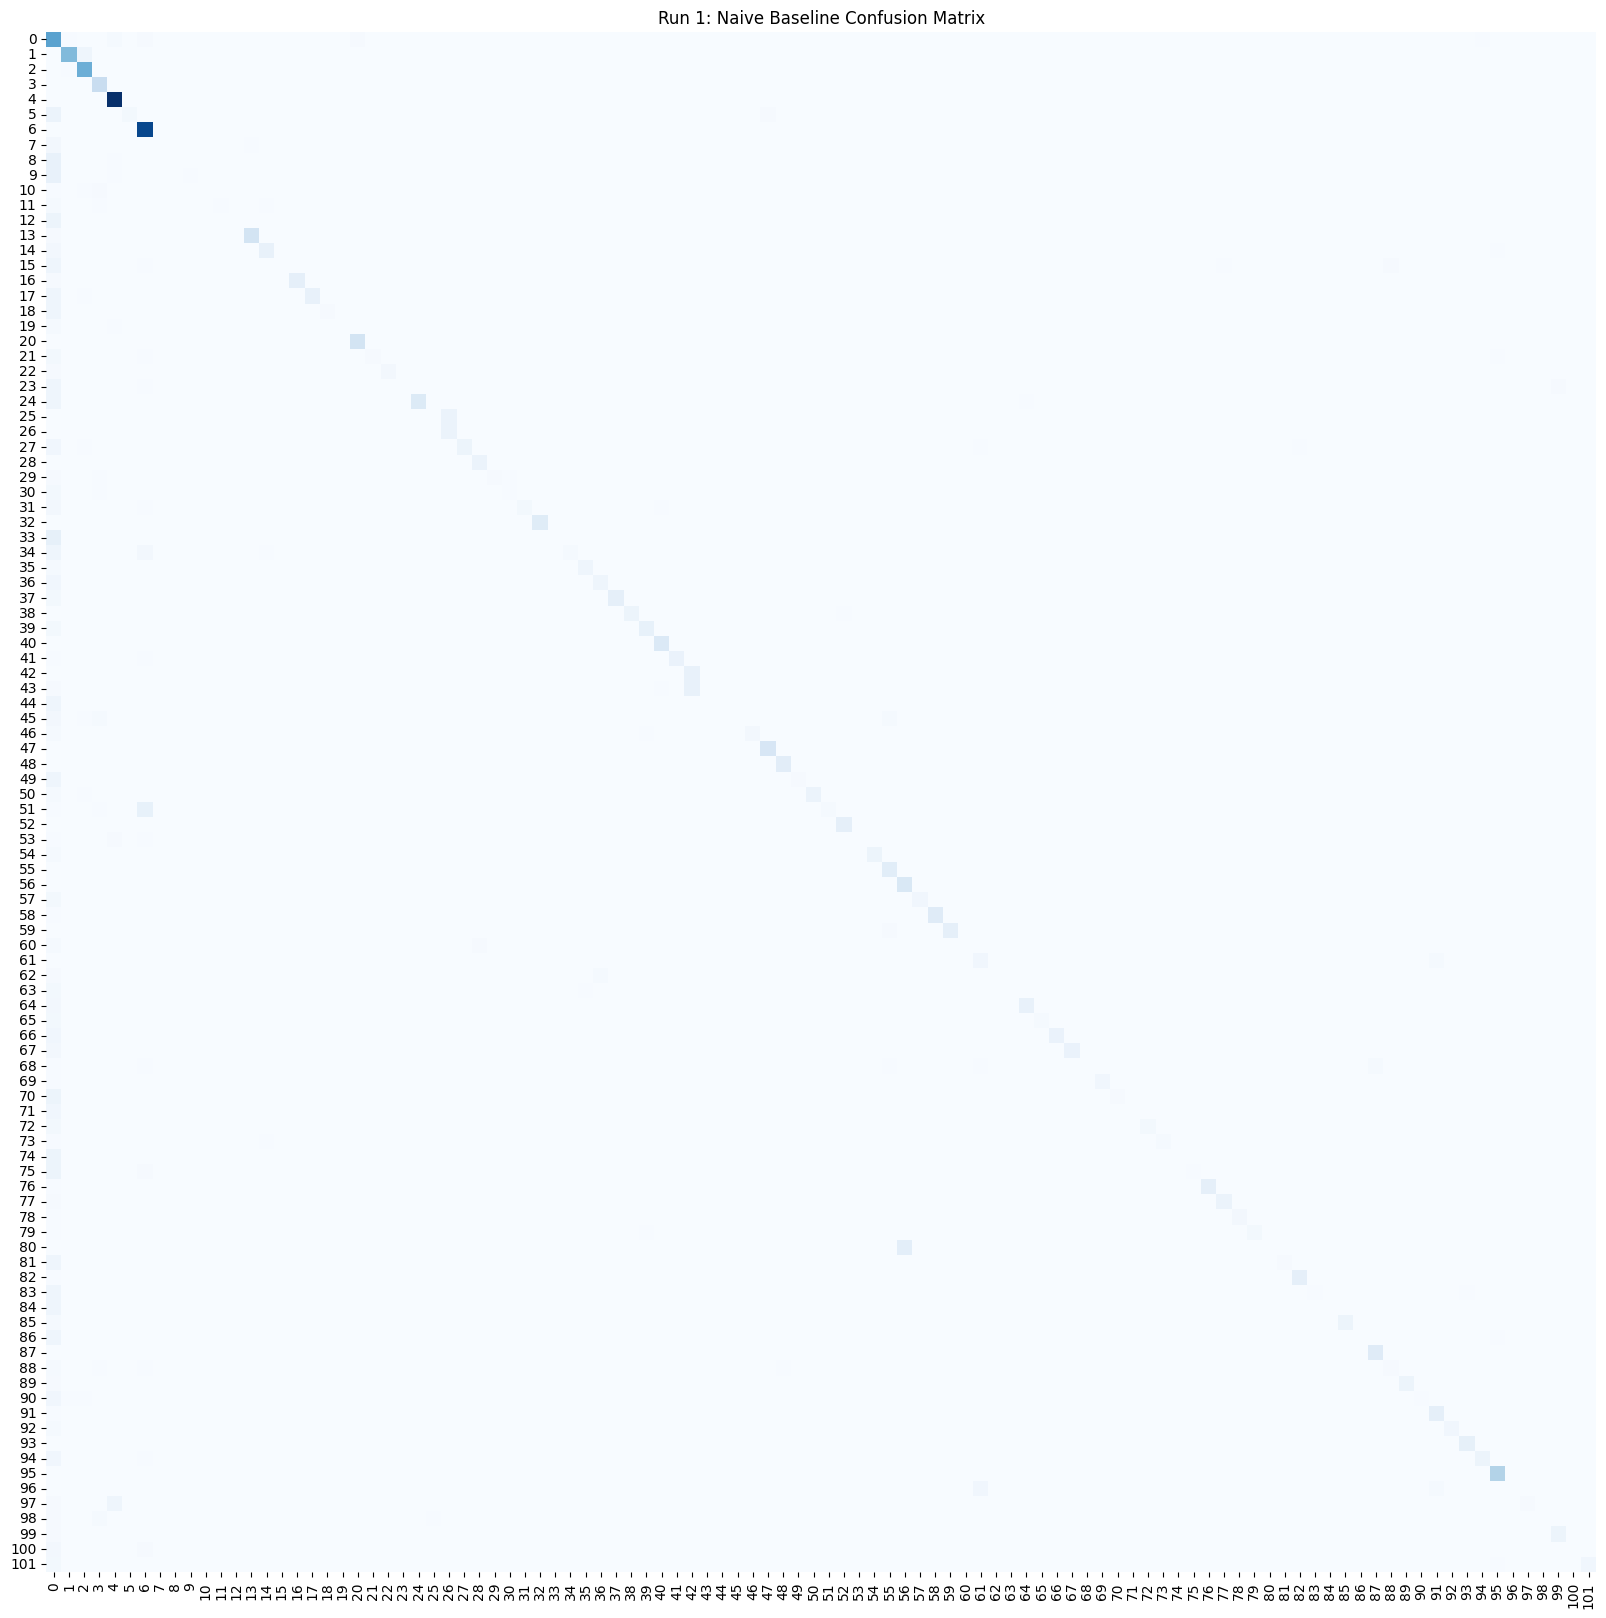

In [10]:
import ssl
import urllib.request

ssl._create_default_https_context = ssl._create_unverified_context

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, models, transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

base_transform = transforms.Compose([
    transforms.Resize((380, 380)), 
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


data_dir = './101_ObjectCategories' 

if not os.path.exists(data_dir):
    data_dir = './data/101_ObjectCategories'

print(f"Loading images from: {data_dir}")
dataset = datasets.ImageFolder(root=data_dir, transform=base_transform)

num_classes = len(dataset.classes)
print(f"Detected {num_classes} object categories.")

# Standard 80/20 Random Split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

print(f"Run 1 Data Ready: {len(train_dataset)} Train | {len(val_dataset)} Val")


def get_model(num_out_nodes):
 
    model = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)
    
    for param in model.parameters():
        param.requires_grad = False
        
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, num_out_nodes) 
    )
    return model.to(device)

model = get_model(num_classes)
criterion = nn.CrossEntropyLoss() 
optimizer = optim.AdamW(model.classifier.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)


num_epochs = 15

print("\nStarting Run 1 (Naive Baseline) Training...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        
    scheduler.step()
    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{num_epochs} | Training Loss: {epoch_loss:.4f}")


model.eval()
y_true = []
y_pred = []

print("\nEvaluating Run 1...")
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("\n" + "="*50)
print("RUN 1: NAIVE BASELINE CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, digits=4, target_names=dataset.classes))


cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20, 20))
sns.heatmap(cm, cmap='Blues', cbar=False)
plt.title('Run 1: Naive Baseline Confusion Matrix')
plt.savefig('run1_confusion_matrix.png')
print("Confusion matrix saved successfully as 'run1_confusion_matrix.png'")

PREPARING RUN 2: STRATIFIED SPLIT (DISTRIBUTION FIX)
Run 2 Stratified Data Ready: 7315 Train | 1829 Val

Starting Run 2 (Stratified Split) Training...
Epoch 1/15 | Training Loss: 4.2715
Epoch 2/15 | Training Loss: 3.6895
Epoch 3/15 | Training Loss: 3.2530
Epoch 4/15 | Training Loss: 2.9488
Epoch 5/15 | Training Loss: 2.7030
Epoch 6/15 | Training Loss: 2.5142
Epoch 7/15 | Training Loss: 2.3477
Epoch 8/15 | Training Loss: 2.2285
Epoch 9/15 | Training Loss: 2.1316
Epoch 10/15 | Training Loss: 2.0471
Epoch 11/15 | Training Loss: 1.9967
Epoch 12/15 | Training Loss: 1.9639
Epoch 13/15 | Training Loss: 1.9359
Epoch 14/15 | Training Loss: 1.9190
Epoch 15/15 | Training Loss: 1.9181

Evaluating Run 2...

RUN 2: STRATIFIED SPLIT CLASSIFICATION REPORT
                   precision    recall  f1-score   support

BACKGROUND_Google     0.2198    0.8602    0.3501        93
            Faces     0.9583    0.7931    0.8679        87
       Faces_easy     0.8019    0.9770    0.8808        87
         Leop

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

Confusion matrix saved successfully as 'run2_confusion_matrix.png'


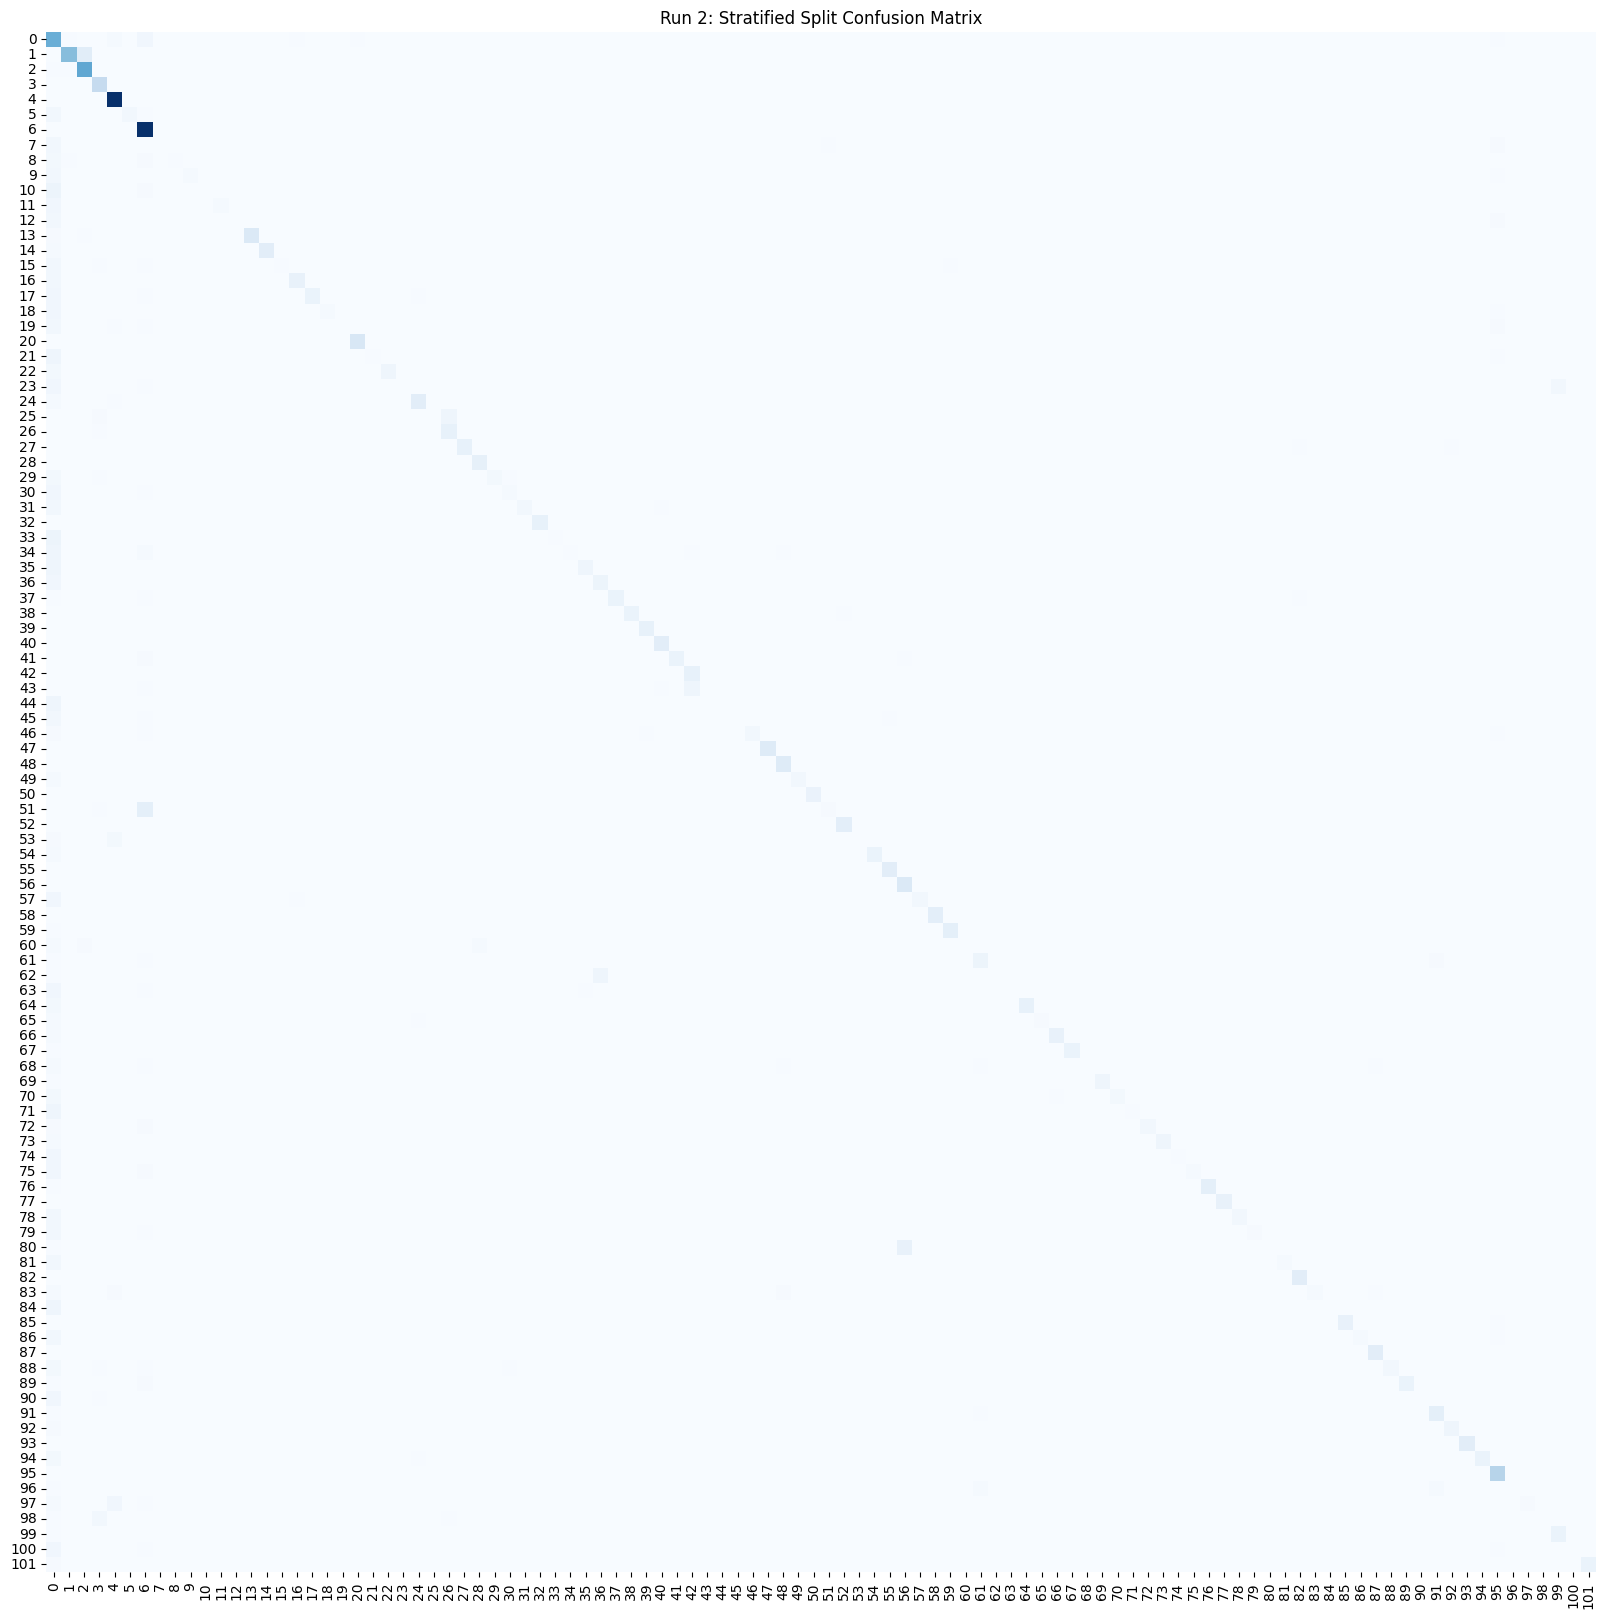

In [11]:
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import Subset
import copy

print("="*50)
print("PREPARING RUN 2: STRATIFIED SPLIT (DISTRIBUTION FIX)")
print("="*50)


targets = dataset.targets 

# Force exactly a 20% split for every individual class
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, val_idx in splitter.split(np.zeros(len(targets)), targets):
    train_indices = train_idx
    val_indices = val_idx


train_dataset_strat = Subset(dataset, train_indices)
val_dataset_strat = Subset(dataset, val_indices)

train_loader_strat = DataLoader(train_dataset_strat, batch_size=16, shuffle=True, num_workers=0)
val_loader_strat = DataLoader(val_dataset_strat, batch_size=16, shuffle=False, num_workers=0)

print(f"Run 2 Stratified Data Ready: {len(train_dataset_strat)} Train | {len(val_dataset_strat)} Val")

model_run2 = get_model(num_classes)
criterion_run2 = nn.CrossEntropyLoss() 
optimizer_run2 = optim.AdamW(model_run2.classifier.parameters(), lr=1e-4)
scheduler_run2 = optim.lr_scheduler.CosineAnnealingLR(optimizer_run2, T_max=15)

num_epochs = 15

print("\nStarting Run 2 (Stratified Split) Training...")
for epoch in range(num_epochs):
    model_run2.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader_strat:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer_run2.zero_grad()
        outputs = model_run2(inputs)
        loss = criterion_run2(outputs, labels)
        
        loss.backward()
        optimizer_run2.step()
        running_loss += loss.item() * inputs.size(0)
        
    scheduler_run2.step()
    epoch_loss = running_loss / len(train_loader_strat.dataset)
    print(f"Epoch {epoch+1}/{num_epochs} | Training Loss: {epoch_loss:.4f}")

model_run2.eval()
y_true_run2 = []
y_pred_run2 = []

print("\nEvaluating Run 2...")
with torch.no_grad():
    for inputs, labels in val_loader_strat:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_run2(inputs)
        _, preds = torch.max(outputs, 1)
        
        y_true_run2.extend(labels.cpu().numpy())
        y_pred_run2.extend(preds.cpu().numpy())

print("\n" + "="*50)
print("RUN 2: STRATIFIED SPLIT CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true_run2, y_pred_run2, digits=4, target_names=dataset.classes))

cm_run2 = confusion_matrix(y_true_run2, y_pred_run2)
plt.figure(figsize=(20, 20))
sns.heatmap(cm_run2, cmap='Blues', cbar=False)
plt.title('Run 2: Stratified Split Confusion Matrix')
plt.savefig('run2_confusion_matrix.png')
print("Confusion matrix saved successfully as 'run2_confusion_matrix.png'")

PREPARING RUN 3: THE VARIANCE ENGINE (AUTOAUGMENT)
Run 3 Augmented Data Ready: 7315 Train | 1829 Val

Starting Run 3 (AutoAugment) Training...
Epoch 1/15 | Training Loss: 4.2951
Epoch 2/15 | Training Loss: 3.7498
Epoch 3/15 | Training Loss: 3.3292
Epoch 4/15 | Training Loss: 3.0282
Epoch 5/15 | Training Loss: 2.7936
Epoch 6/15 | Training Loss: 2.6022
Epoch 7/15 | Training Loss: 2.4578
Epoch 8/15 | Training Loss: 2.3293
Epoch 9/15 | Training Loss: 2.2375
Epoch 10/15 | Training Loss: 2.1653
Epoch 11/15 | Training Loss: 2.1127
Epoch 12/15 | Training Loss: 2.0793
Epoch 13/15 | Training Loss: 2.0505
Epoch 14/15 | Training Loss: 2.0405
Epoch 15/15 | Training Loss: 2.0339

Evaluating Run 3...

RUN 3: AUTOAUGMENT CLASSIFICATION REPORT
                   precision    recall  f1-score   support

BACKGROUND_Google     0.2431    0.8495    0.3780        93
            Faces     0.9367    0.8506    0.8916        87
       Faces_easy     0.7885    0.9425    0.8586        87
         Leopards     0.80

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

Confusion matrix saved successfully as 'run3_confusion_matrix.png'


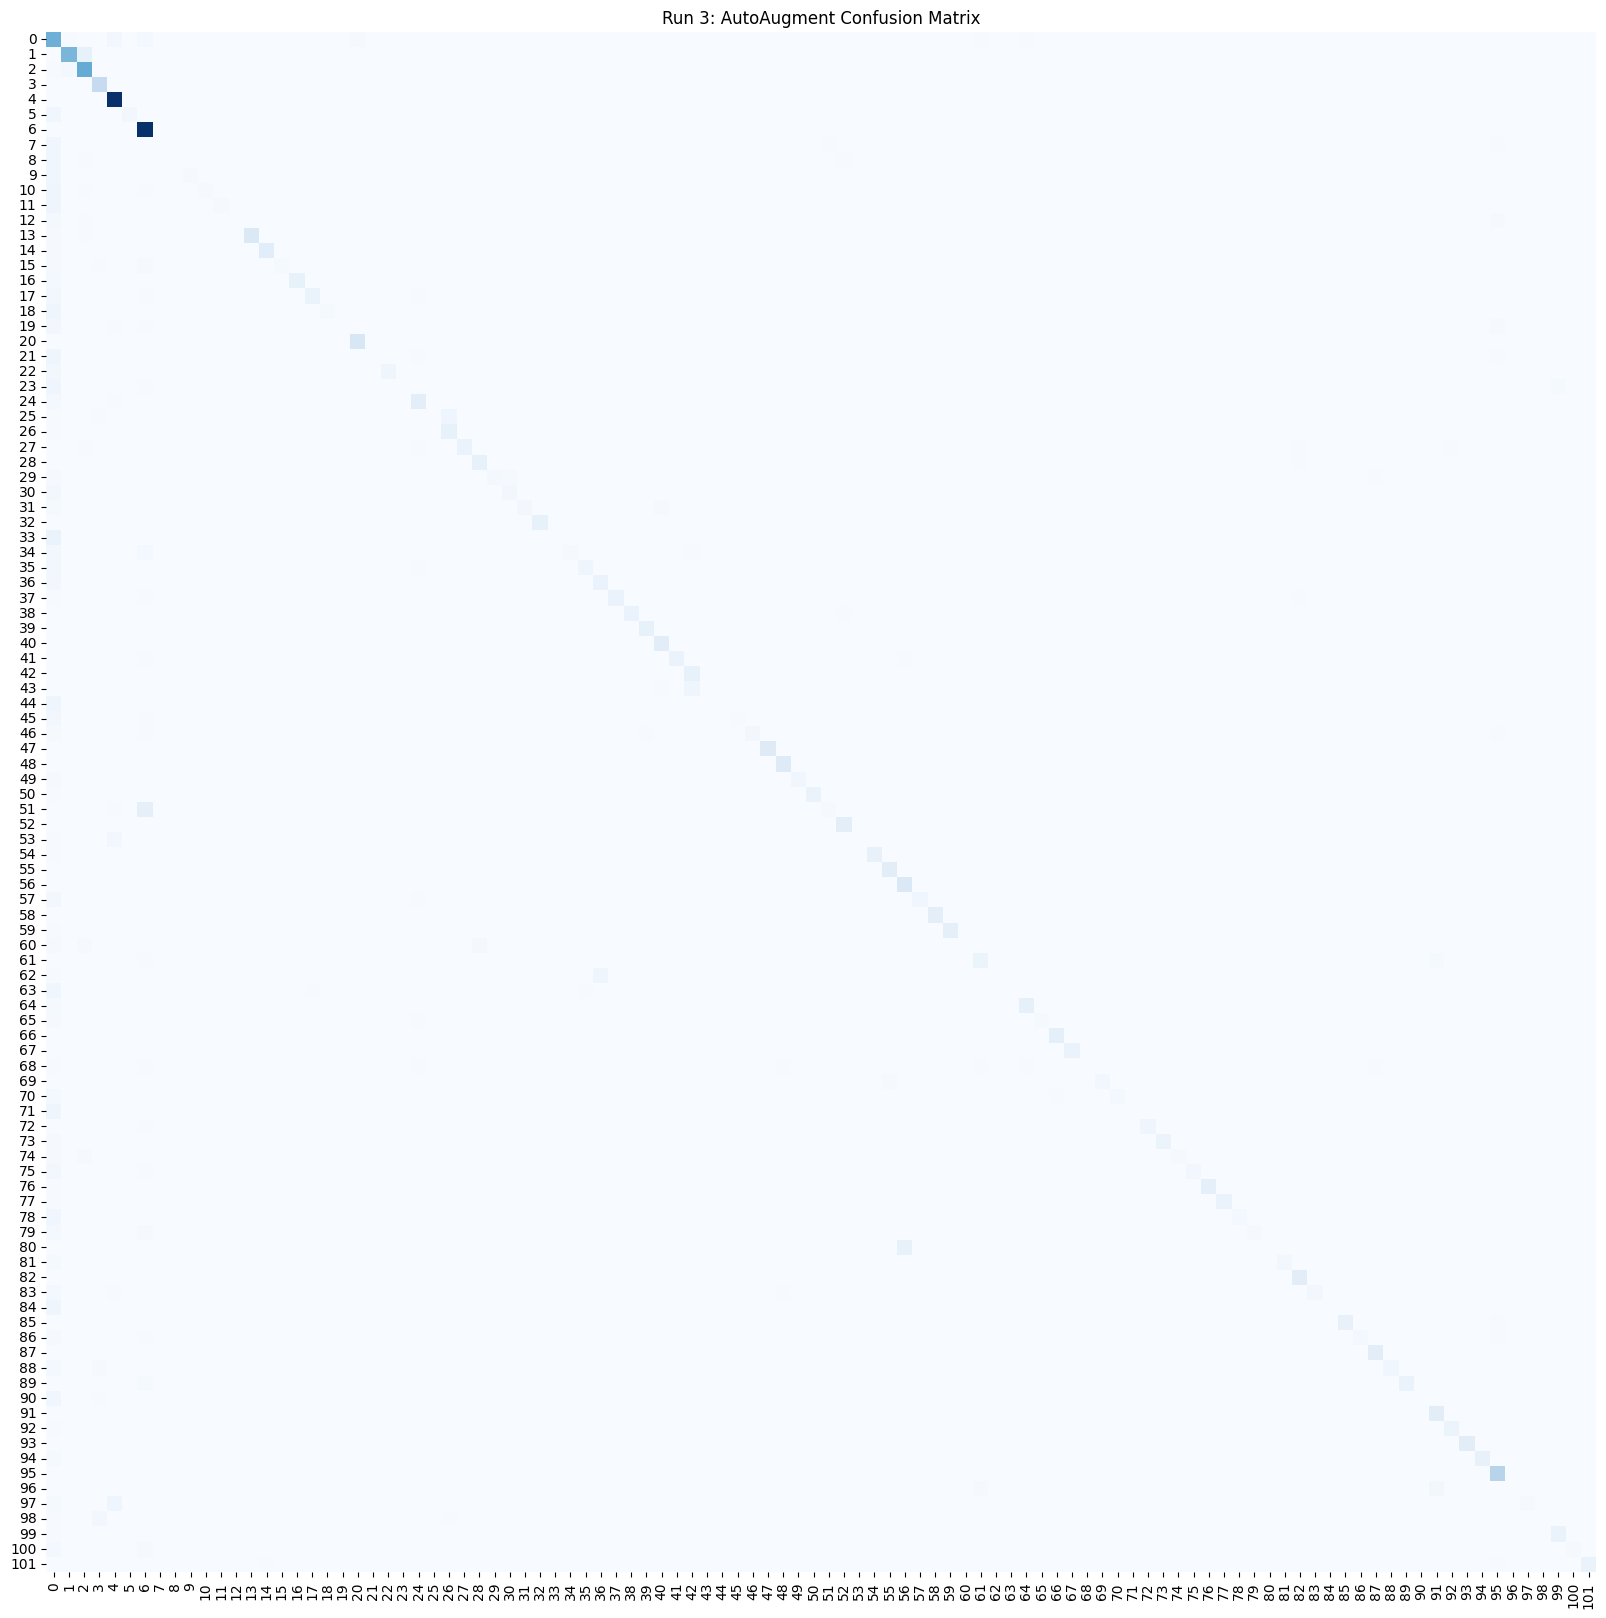

In [12]:
print("="*50)
print("PREPARING RUN 3: THE VARIANCE ENGINE (AUTOAUGMENT)")
print("="*50)

augment_transform = transforms.Compose([
    transforms.Resize((380, 380)),
    transforms.AutoAugment(policy=transforms.AutoAugmentPolicy.IMAGENET), # The Magic
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dataset_aug = datasets.ImageFolder(root=data_dir, transform=augment_transform)
dataset_base = datasets.ImageFolder(root=data_dir, transform=base_transform)

train_dataset_aug = Subset(dataset_aug, train_indices)
val_dataset_base = Subset(dataset_base, val_indices)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=16, shuffle=True, num_workers=0)
val_loader_base = DataLoader(val_dataset_base, batch_size=16, shuffle=False, num_workers=0)

print(f"Run 3 Augmented Data Ready: {len(train_dataset_aug)} Train | {len(val_dataset_base)} Val")

model_run3 = get_model(num_classes)
criterion_run3 = nn.CrossEntropyLoss() 
optimizer_run3 = optim.AdamW(model_run3.classifier.parameters(), lr=1e-4)
scheduler_run3 = optim.lr_scheduler.CosineAnnealingLR(optimizer_run3, T_max=15)

num_epochs = 15

print("\nStarting Run 3 (AutoAugment) Training...")
for epoch in range(num_epochs):
    model_run3.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader_aug:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer_run3.zero_grad()
        outputs = model_run3(inputs)
        loss = criterion_run3(outputs, labels)
        
        loss.backward()
        optimizer_run3.step()
        running_loss += loss.item() * inputs.size(0)
        
    scheduler_run3.step()
    epoch_loss = running_loss / len(train_loader_aug.dataset)
    print(f"Epoch {epoch+1}/{num_epochs} | Training Loss: {epoch_loss:.4f}")

model_run3.eval()
y_true_run3 = []
y_pred_run3 = []

print("\nEvaluating Run 3...")
with torch.no_grad():
    for inputs, labels in val_loader_base:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_run3(inputs)
        _, preds = torch.max(outputs, 1)
        
        y_true_run3.extend(labels.cpu().numpy())
        y_pred_run3.extend(preds.cpu().numpy())

print("\n" + "="*50)
print("RUN 3: AUTOAUGMENT CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true_run3, y_pred_run3, digits=4, target_names=dataset.classes))

cm_run3 = confusion_matrix(y_true_run3, y_pred_run3)
plt.figure(figsize=(20, 20))
sns.heatmap(cm_run3, cmap='Blues', cbar=False)
plt.title('Run 3: AutoAugment Confusion Matrix')
plt.savefig('run3_confusion_matrix.png')
print("Confusion matrix saved successfully as 'run3_confusion_matrix.png'")

PREPARING RUN 4: SOTA MASTERPIECE (WEIGHTED LOSS)
Class weights successfully calculated and loaded onto the device.

Starting Run 4 (Weighted Loss) Training...
Epoch 1/15 | Training Loss: 4.4947
Epoch 2/15 | Training Loss: 4.2185
Epoch 3/15 | Training Loss: 3.9563
Epoch 4/15 | Training Loss: 3.7165
Epoch 5/15 | Training Loss: 3.4972
Epoch 6/15 | Training Loss: 3.3073
Epoch 7/15 | Training Loss: 3.1434
Epoch 8/15 | Training Loss: 3.0187
Epoch 9/15 | Training Loss: 2.9059
Epoch 10/15 | Training Loss: 2.8253
Epoch 11/15 | Training Loss: 2.7650
Epoch 12/15 | Training Loss: 2.7228
Epoch 13/15 | Training Loss: 2.6890
Epoch 14/15 | Training Loss: 2.6910
Epoch 15/15 | Training Loss: 2.6718

Evaluating Run 4...

RUN 4: WEIGHTED LOSS CLASSIFICATION REPORT
                   precision    recall  f1-score   support

BACKGROUND_Google     0.8250    0.3548    0.4962        93
            Faces     0.9688    0.7126    0.8212        87
       Faces_easy     0.7727    0.9770    0.8629        87
       

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

Confusion matrix saved successfully as 'run4_confusion_matrix.png'


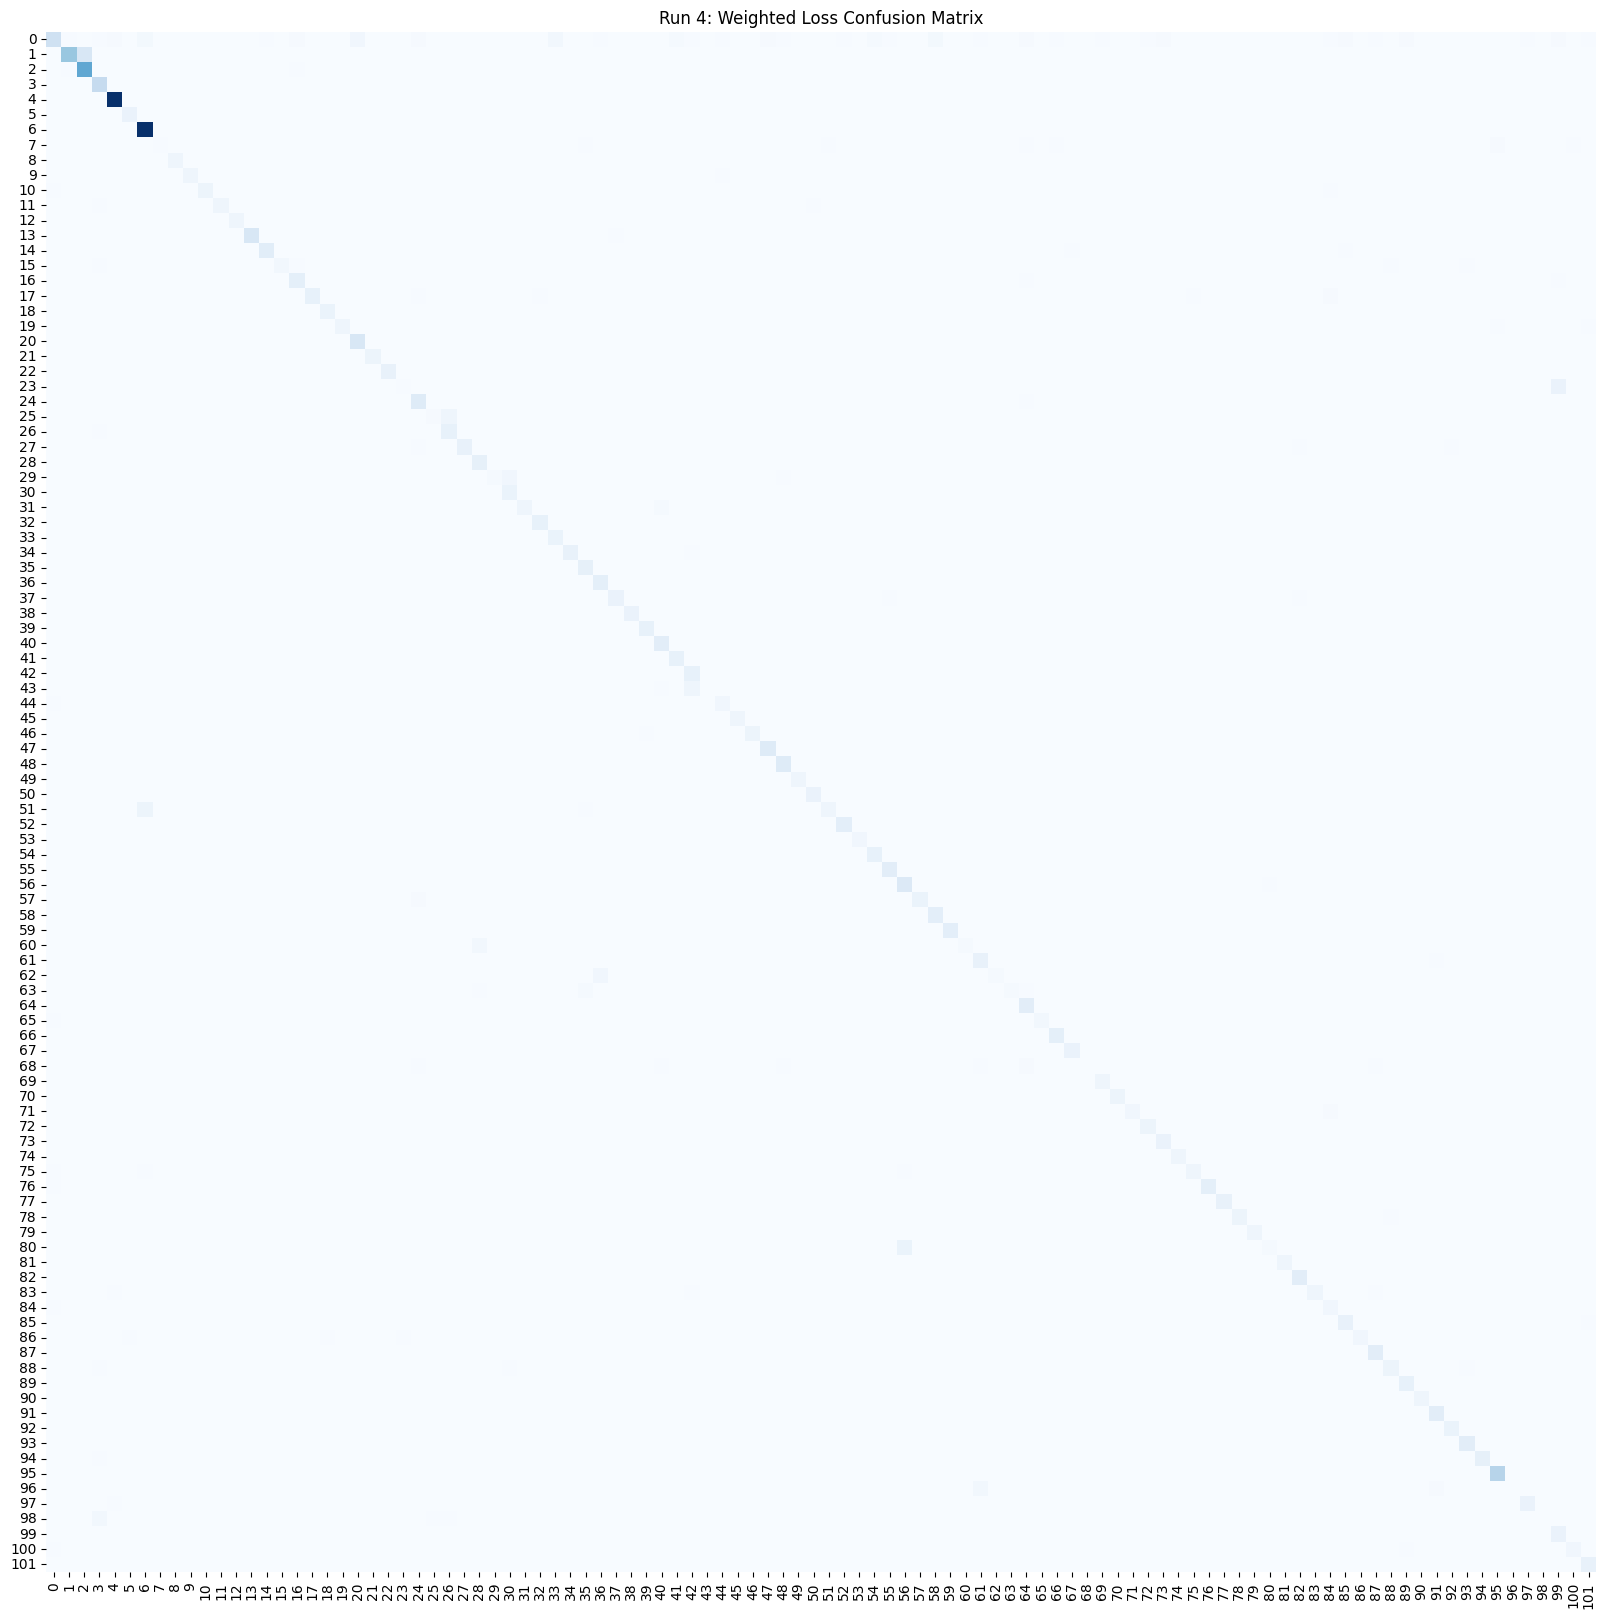

In [13]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("="*50)
print("PREPARING RUN 4: SOTA MASTERPIECE (WEIGHTED LOSS)")
print("="*50)

train_labels = [dataset_aug.targets[i] for i in train_indices]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights successfully calculated and loaded onto the device.")

model_run4 = get_model(num_classes)

criterion_run4 = nn.CrossEntropyLoss(weight=weights_tensor) 

optimizer_run4 = optim.AdamW(model_run4.classifier.parameters(), lr=1e-4)
scheduler_run4 = optim.lr_scheduler.CosineAnnealingLR(optimizer_run4, T_max=15)

num_epochs = 15

print("\nStarting Run 4 (Weighted Loss) Training...")
for epoch in range(num_epochs):
    model_run4.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader_aug:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer_run4.zero_grad()
        outputs = model_run4(inputs)
        loss = criterion_run4(outputs, labels)
        
        loss.backward()
        optimizer_run4.step()
        running_loss += loss.item() * inputs.size(0)
        
    scheduler_run4.step()
    epoch_loss = running_loss / len(train_loader_aug.dataset)
    print(f"Epoch {epoch+1}/{num_epochs} | Training Loss: {epoch_loss:.4f}")

model_run4.eval()
y_true_run4 = []
y_pred_run4 = []

print("\nEvaluating Run 4...")
with torch.no_grad():
    for inputs, labels in val_loader_base:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_run4(inputs)
        _, preds = torch.max(outputs, 1)
        
        y_true_run4.extend(labels.cpu().numpy())
        y_pred_run4.extend(preds.cpu().numpy())

print("\n" + "="*50)
print("RUN 4: WEIGHTED LOSS CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true_run4, y_pred_run4, digits=4, target_names=dataset.classes))

cm_run4 = confusion_matrix(y_true_run4, y_pred_run4)
plt.figure(figsize=(20, 20))
sns.heatmap(cm_run4, cmap='Blues', cbar=False)
plt.title('Run 4: Weighted Loss Confusion Matrix')
plt.savefig('run4_confusion_matrix.png')
print("Confusion matrix saved successfully as 'run4_confusion_matrix.png'")

In [14]:
import torch

print("="*50)
print("SAVING ALL ABLATION MODELS TO DISK")
print("="*50)


torch.save(model.state_dict(), 'run1_naive_baseline.pth')
print("✅ Run 1 Model saved as: run1_naive_baseline.pth")


torch.save(model_run2.state_dict(), 'run2_stratified_split.pth')
print("✅ Run 2 Model saved as: run2_stratified_split.pth")

torch.save(model_run3.state_dict(), 'run3_autoaugment.pth')
print("✅ Run 3 Model saved as: run3_autoaugment.pth")

torch.save(model_run4.state_dict(), 'run4_weighted_loss_sota.pth')
print("✅ Run 4 Model saved as: run4_weighted_loss_sota.pth")

print("\nAll 4 models successfully secured to your hard drive!")

SAVING ALL ABLATION MODELS TO DISK
✅ Run 1 Model saved as: run1_naive_baseline.pth
✅ Run 2 Model saved as: run2_stratified_split.pth
✅ Run 3 Model saved as: run3_autoaugment.pth
✅ Run 4 Model saved as: run4_weighted_loss_sota.pth

All 4 models successfully secured to your hard drive!


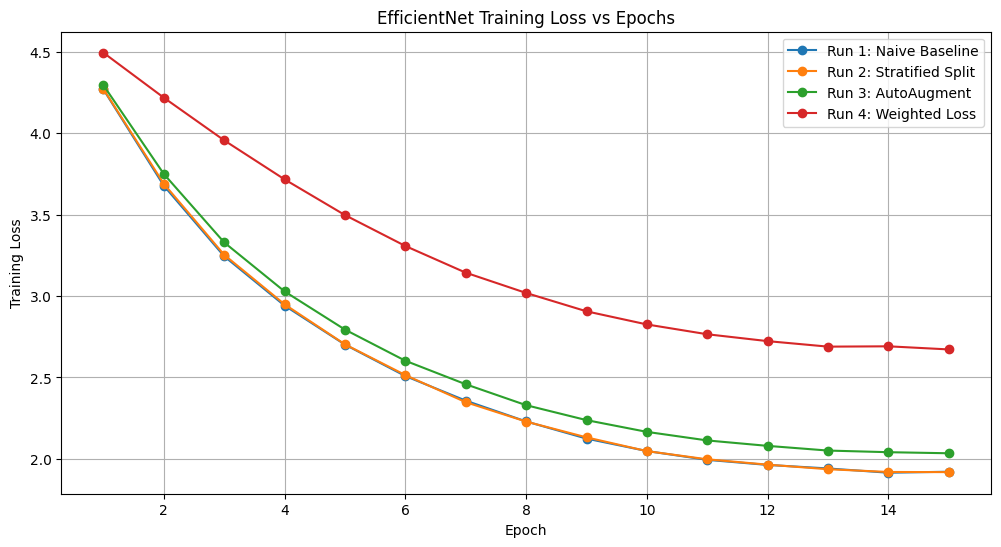

Saved as efficientnet_training_loss.png


In [1]:
import matplotlib.pyplot as plt


# EfficientNet Training Loss Graph (Hardcoded, using values given by training)

epochs = list(range(1, 16))

run1 = [4.2692, 3.6778, 3.2441, 2.9411, 2.7015,
        2.5083, 2.3571, 2.2293, 2.1240, 2.0475,
        1.9934, 1.9623, 1.9406, 1.9144, 1.9206]

run2 = [4.2715, 3.6895, 3.2530, 2.9488, 2.7030,
        2.5142, 2.3477, 2.2285, 2.1316, 2.0471,
        1.9967, 1.9639, 1.9359, 1.9190, 1.9181]

run3 = [4.2951, 3.7498, 3.3292, 3.0282, 2.7936,
        2.6022, 2.4578, 2.3293, 2.2375, 2.1653,
        2.1127, 2.0793, 2.0505, 2.0405, 2.0339]

run4 = [4.4947, 4.2185, 3.9563, 3.7165, 3.4972,
        3.3073, 3.1434, 3.0187, 2.9059, 2.8253,
        2.7650, 2.7228, 2.6890, 2.6910, 2.6718]

plt.figure(figsize=(12, 6))

plt.plot(epochs, run1, marker='o', label='Run 1: Naive Baseline')
plt.plot(epochs, run2, marker='o', label='Run 2: Stratified Split')
plt.plot(epochs, run3, marker='o', label='Run 3: AutoAugment')
plt.plot(epochs, run4, marker='o', label='Run 4: Weighted Loss')

plt.title("EfficientNet Training Loss vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)

plt.savefig("efficientnet_training_loss.png", dpi=300, bbox_inches='tight')

plt.show()

print("Saved as efficientnet_training_loss.png")